# 03 - Exploratory Data Analysis (EDA)

**Project:** Customer Financial Behavior Analysis for Banking Business Intelligence

Notebook ini berisi analisis eksploratif untuk memahami pola transaksi, karakteristik pelanggan, dan menghasilkan insight bisnis.


In [ ]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

# Load cleaned dataset
df = pd.read_csv("bank_transactions_clean.csv")
df.head()


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [ ]:
# Statistik Ringkas
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,2402,2375,TX000026,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,2402,495,AC00202,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmount,2402.0,NaN,NaN,NaN,254.637827,215.686804,0.26,78.9225,200.015,371.075,896.79
PreviousTransactionDate,2402,2374,2023-01-02 16:45:05,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionType,2402,2,Debit,1860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2402,43,Fort Worth,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceID,2402,680,D000203,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP Address,2402,590,200.136.146.93,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MerchantID,2402,100,M026,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2402,3,Branch,854,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Univariat Analysis

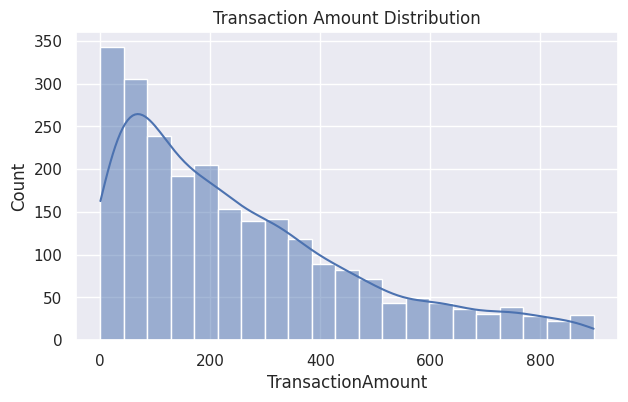

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["TransactionAmount"], kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

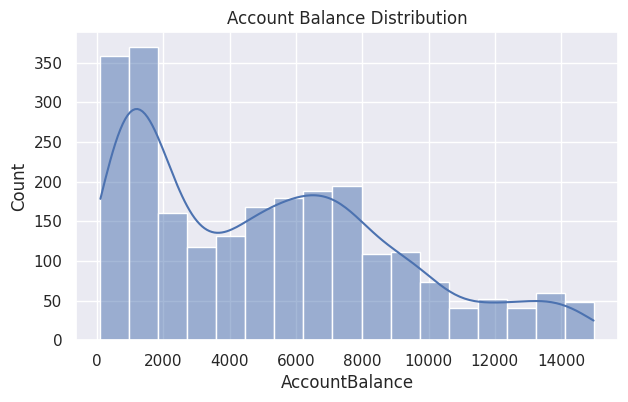

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["AccountBalance"], kde=True)
plt.title("Account Balance Distribution")
plt.show()

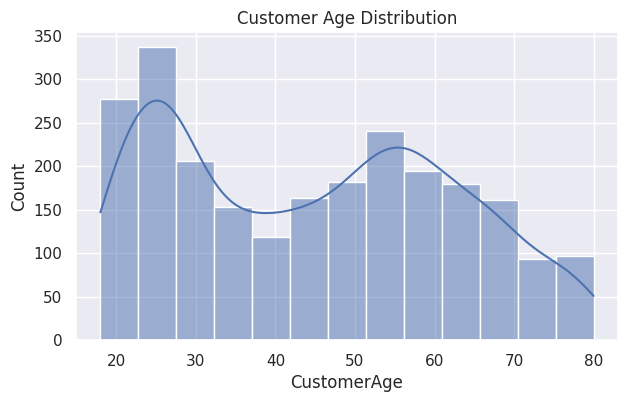

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["CustomerAge"], kde=True)
plt.title("Customer Age Distribution")
plt.show()

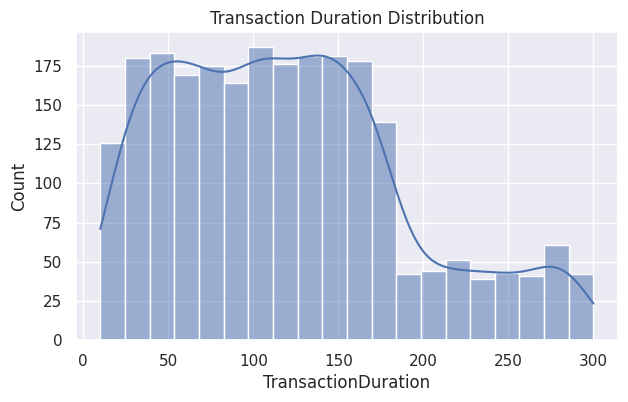

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["TransactionDuration"], kde=True)
plt.title("Transaction Duration Distribution")
plt.show()

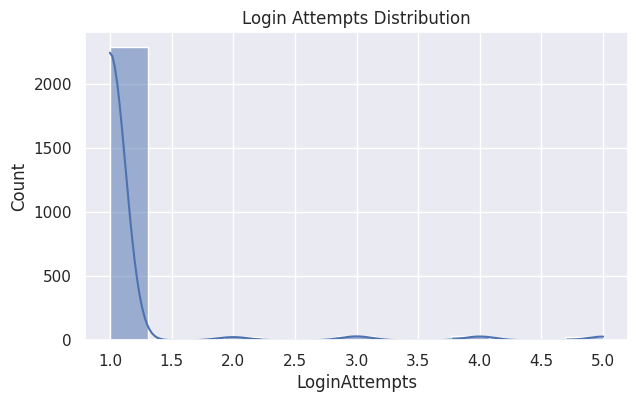

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["LoginAttempts"], kde=True)
plt.title("Login Attempts Distribution")
plt.show()

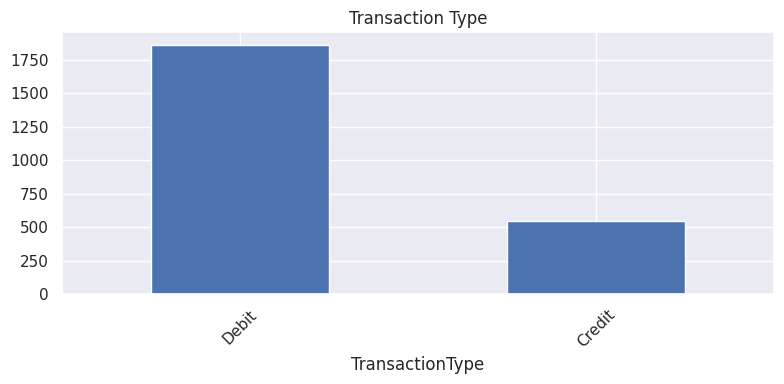

In [ ]:
plt.figure(figsize=(8,4))
df["TransactionType"].value_counts().plot(kind="bar")
plt.title("Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

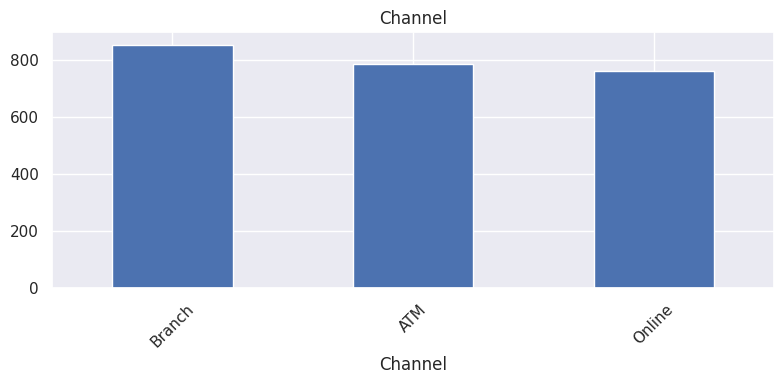

In [ ]:
plt.figure(figsize=(8,4))
df["Channel"].value_counts().plot(kind="bar")
plt.title("Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

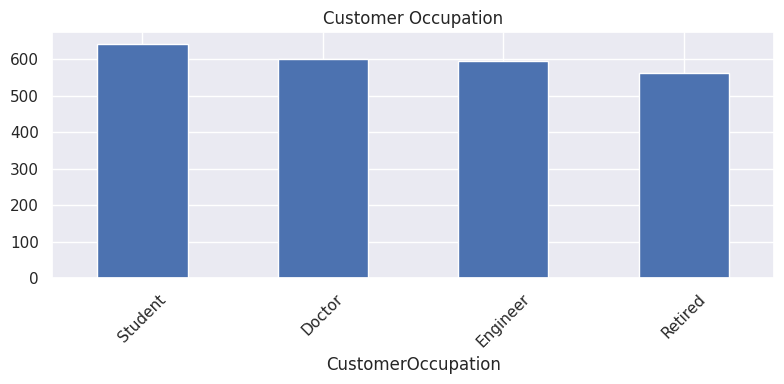

In [ ]:
plt.figure(figsize=(8,4))
df["CustomerOccupation"].value_counts().plot(kind="bar")
plt.title("Customer Occupation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

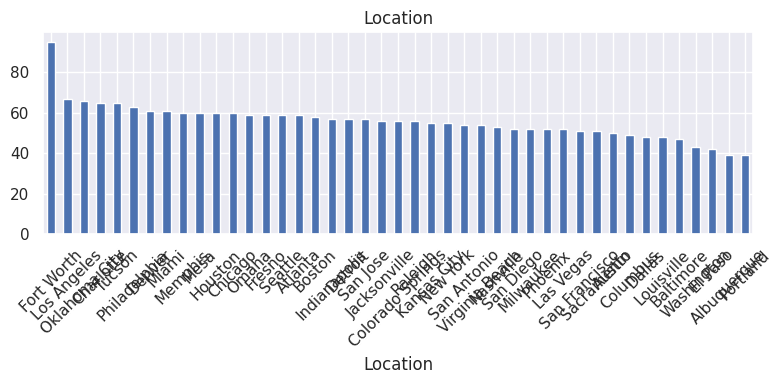

In [ ]:
plt.figure(figsize=(8,4))
df["Location"].value_counts().plot(kind="bar")
plt.title("Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bivariat Analysis

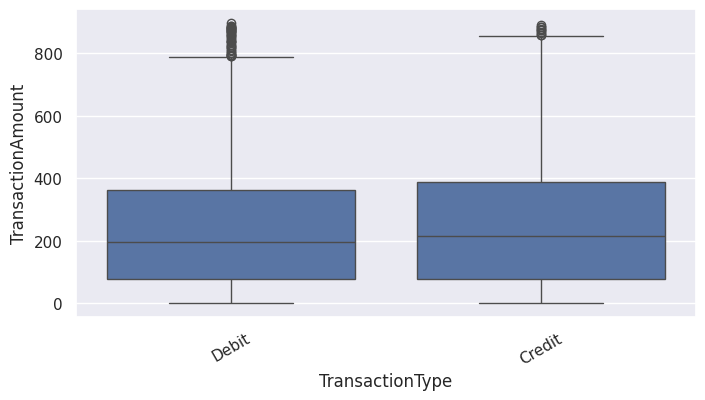

In [ ]:
# Transaction Amount by Transaction Type
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="TransactionType",y="TransactionAmount")
plt.xticks(rotation=30)
plt.show()


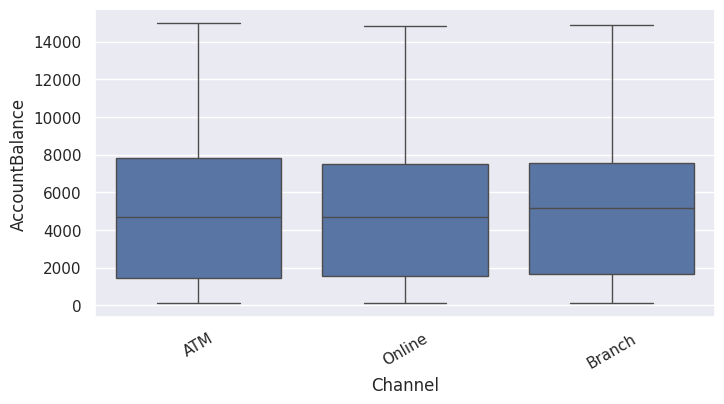

In [ ]:
# Account Balance by Channel
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="Channel",y="AccountBalance")
plt.xticks(rotation=30)
plt.show()


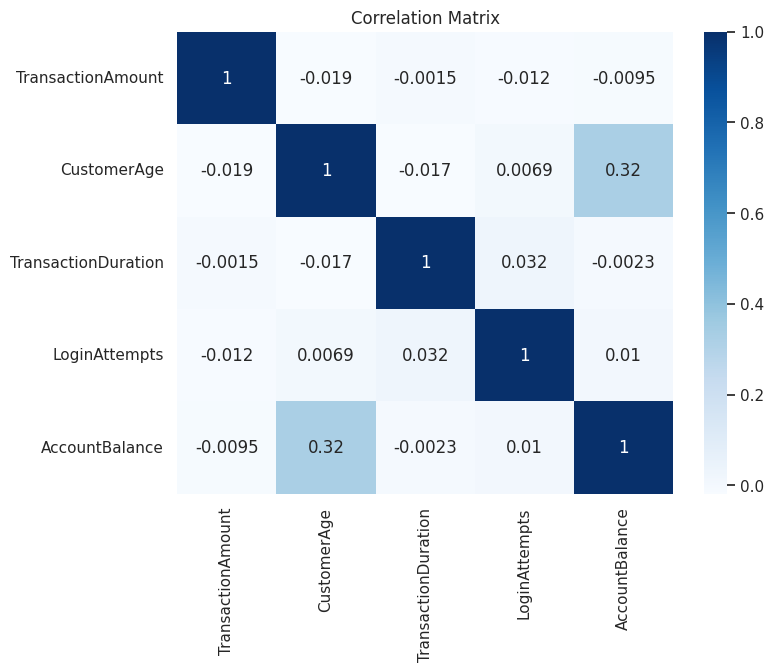

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr=df.select_dtypes(include=["number"]).corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="Blues")
plt.title("Correlation Matrix")
plt.show()


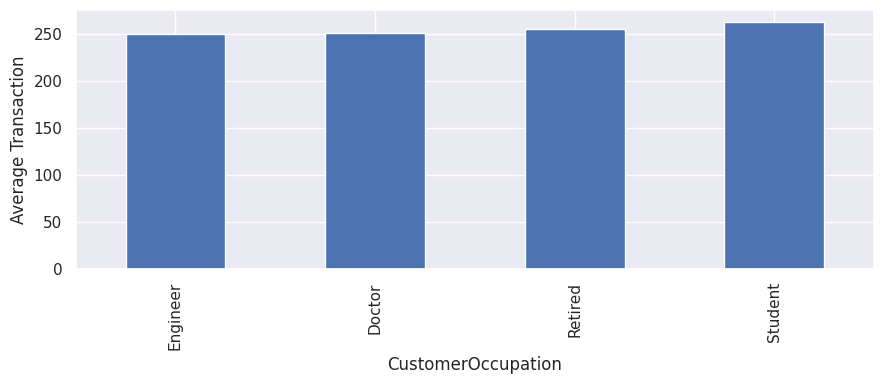

In [ ]:
# Average Transaction by Occupation
avg=df.groupby("CustomerOccupation")["TransactionAmount"].mean().sort_values()

plt.figure(figsize=(9,4))
avg.plot(kind="bar")
plt.ylabel("Average Transaction")
plt.tight_layout()
plt.show()


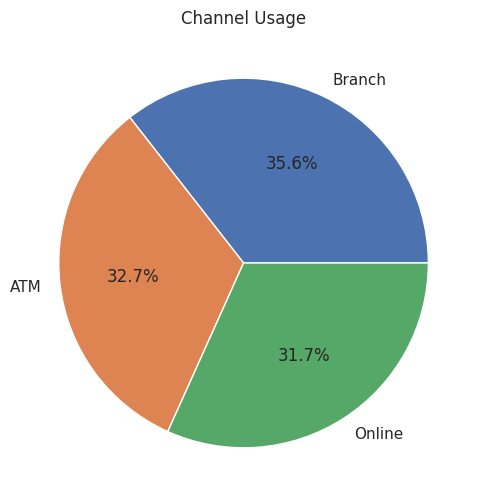

In [ ]:
# Channel Usage
channel=df["Channel"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(channel.values,labels=channel.index,autopct="%1.1f%%")
plt.title("Channel Usage")
plt.show()


## Business Insights

Setelah seluruh visualisasi selesai, tuliskan insight untuk setiap grafik, misalnya:

- Distribusi nominal transaksi.
- Kelompok usia yang dominan.
- Channel transaksi paling populer.
- Jenis transaksi yang paling sering digunakan.
- Perbedaan saldo berdasarkan channel.
- Hubungan antar variabel numerik.
- Implikasi bisnis untuk strategi pemasaran dan layanan digital.
